# Cluster maps $z_{min}$ comparison

In [3]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
%matplotlib inline
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table
import pyccl as ccl
import fitsio
from ulid import ULID

from simulMap import *
from fitMap import *
from cluster import *
from mappers import CountMapper

In [2]:
#resolution:
nside = 64
npix = hp.nside2npix(nside)
print("Number of pixels = {}".format(npix))

#sources:
NSource_px_th = int(1e6)
print("Total number of sources in the entire sky : {}".format(NSource_px_th*npix))
print("Theorical number of sources in one pixel : {}".format(NSource_px_th))

Number of pixels = 49152
Total number of sources in the entire sky : 49152000000
Theorical number of sources in one pixel : 1000000


## Power spectrum

In [6]:
zmin = [1.e-3, 1.e-2, 1.e-1, 1]
dfMinuit, fit_results = [], []
for i in range(len(zmin)):
    print('i =', i, end='\t')
    zm = zmin[i]
    cl, ell = get_Cl_ccl(nside, zmin=zm, get_ell=True)
    NSource_px_Cl = get_clusterContrast(cl, nside, lognormal=False, nest=True)
    clMapper = CountMapper.from_map(NSource_px_Cl)
    monop = apply_monopole_Mcontrast(clMapper.map, NSource_px_th)
    monopMapper = CountMapper.from_map(monop)
    init = (NSource_px_th, 1, 100, 0)
    m = monopMapper.fit_dipole("", init, plot_fig=False, plot_map=False, verbose=False)
    dic_param = get_dicParam_minuit(m, "NaN", add_param={'zmin': zm})
    fit_results.append(m)
    dfMinuit.append(dic_param)

dfMinuit = pd.concat(dfMinuit, ignore_index=True)
dfMinuit

i = 0	

/home/victoria/miniconda3/envs/M2Stage/lib/python3.10/site-packages/pyccl/errors.py:22: CCLWarning: Nchi must be a positive integer. Setting to match tracer with fewest chi samples.
  warnings_builtin.warn(*args, **kwargs)
/home/victoria/miniconda3/envs/M2Stage/lib/python3.10/site-packages/pyccl/errors.py:22: CCLWarning: chi_min must be greater than zero.Setting to default 1e-6 Mpc.
  warnings_builtin.warn(*args, **kwargs)


i = 1	i = 2	i = 3	

,Map_ID,N*,N*_init,N*_err,N*_fixed,N*_limit_0,N*_limit_1,A,A_init,A_err,...,ra_limit_0,ra_limit_1,dec,dec_init,dec_err,dec_fixed,dec_limit_0,dec_limit_1,valid,zmin
0,NaN,997566.792444,1000000.0,4.505054,False,0.0,inf,0.000478,1.0,0.000008,...,0.0,360.0,-0.905311,0.0,0.937424,False,-90.0,90.0,True,0.001
1,NaN,997750.461745,1000000.0,4.505473,False,0.0,inf,0.001022,1.0,0.000008,...,0.0,360.0,-12.406972,0.0,0.438609,False,-90.0,90.0,True,0.010
2,NaN,997719.105936,1000000.0,4.505405,False,0.0,inf,0.000855,1.0,0.000008,...,0.0,360.0,29.429151,0.0,0.524740,False,-90.0,90.0,True,0.100
3,NaN,997929.646809,1000000.0,4.505880,False,0.0,inf,0.000660,1.0,0.000008,...,0.0,360.0,55.844778,0.0,0.679014,False,-90.0,90.0,True,1.000


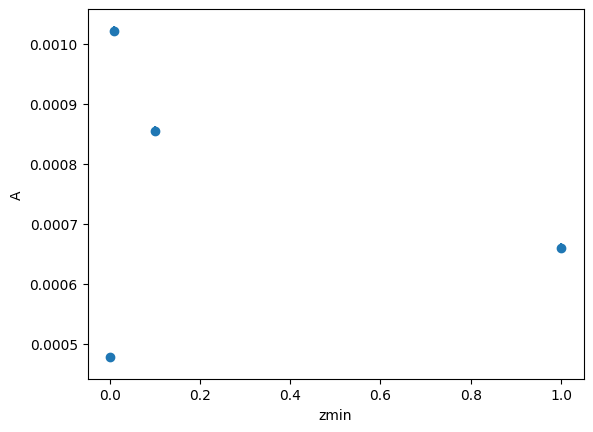

In [10]:
def compare_zmin(df, y="A"):
    plt.errorbar(df['zmin'], df[y], yerr=df[y + '_err'], linestyle='', marker='o')
    plt.xlabel('zmin')
    plt.ylabel(y)

compare_zmin(dfMinuit)

In [11]:
dfMinuit[['zmin', 'A', 'A_err']]

,zmin,A,A_err
0,0.001,0.000478,0.000008
1,0.010,0.001022,0.000008
2,0.100,0.000855,0.000008
3,1.000,0.000660,0.000008


/home/victoria/miniconda3/envs/M2Stage/lib/python3.10/site-packages/pyccl/errors.py:22: CCLWarning: Nchi must be a positive integer. Setting to match tracer with fewest chi samples.
  warnings_builtin.warn(*args, **kwargs)
/home/victoria/miniconda3/envs/M2Stage/lib/python3.10/site-packages/pyccl/errors.py:22: CCLWarning: chi_min must be greater than zero.Setting to default 1e-6 Mpc.
  warnings_builtin.warn(*args, **kwargs)


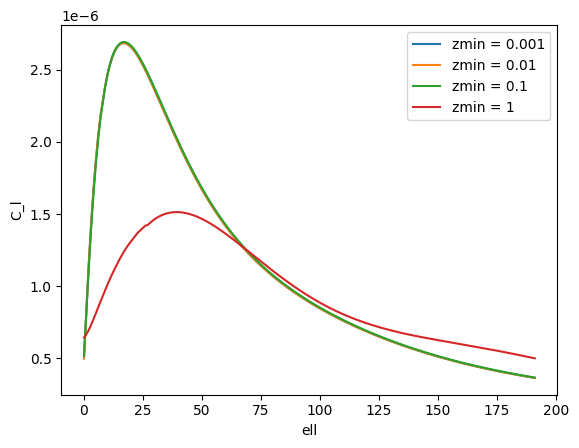

In [12]:
lmin = 1
zmin = [0, 0.01, 0.1, 0.5, 1]
plt.figure(figsize=(12, 6))
for zm in zmin:
    cl, ell = get_Cl_ccl(nside, zm, get_ell=True)
    plt.plot(ell[lmin:], cl[lmin:], label = f"z_min = {zm}")
plt.xlabel('ell')
plt.ylabel('C_l')
plt.legend();

output_path = "Simul_Figures/Simul_Cluster/Simul_Cluster_NoLogNorm/Cluster_NoLogNorm_"
get_savefig(plt, output_path, "Cl_ell")